In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Regresión Lineal Simple

La regresión lineal simple es una técnica estadística que se utiliza para analizar la relación entre dos variables:

- Una variable independiente (X), también llamada predictora o explicativa
- Una variable dependiente (Y), también llamada respuesta o resultado.

El objetivo es estimar una recta que describa la relación entre ambas, de forma que podamos predecir Y a partir de X

### Ejemplo

In [3]:
# Este dataset maneja la cantidad de productos vendidor(miles de unidad)
# Presupuesto de inversión en medios(miles de dólares)
df=pd.read_csv("./publicidad.csv")
df

,TV,radio,impreso,ventas
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [4]:
df.corr()

,TV,radio,impreso,ventas
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
impreso,0.056648,0.354104,1.000000,0.228299
ventas,0.782224,0.576223,0.228299,1.000000


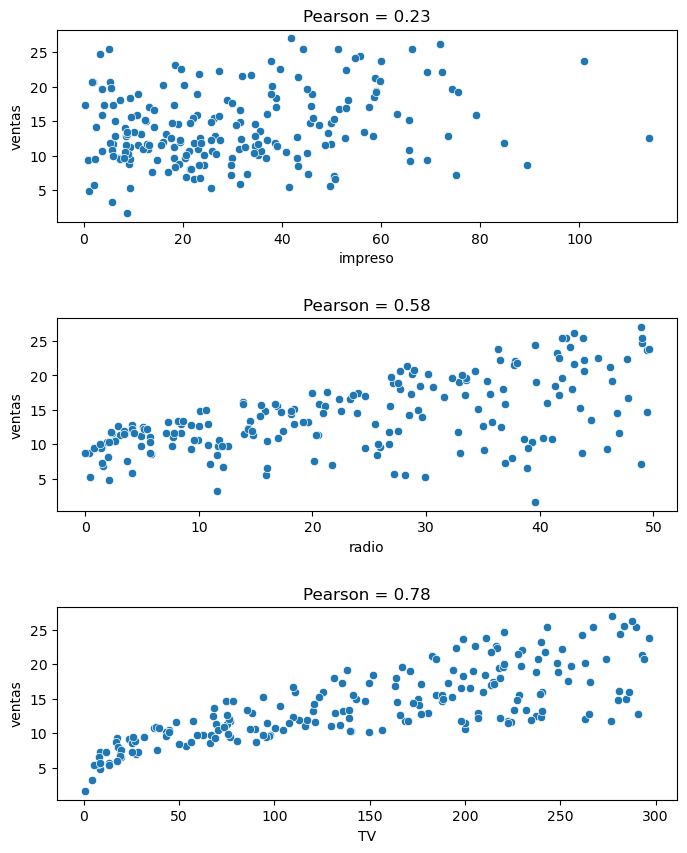

In [5]:
fig,axs=plt.subplots(3,1,figsize=(8,10))
fig.subplots_adjust(hspace=.5)
for ax,col in zip(axs,["impreso","radio","TV"]):
    coef = df['ventas'].corr(df[col])
    ax.set_title(f'Pearson = {coef:.2f}')    
    sns.scatterplot(df,x=col,y="ventas",ax=ax)

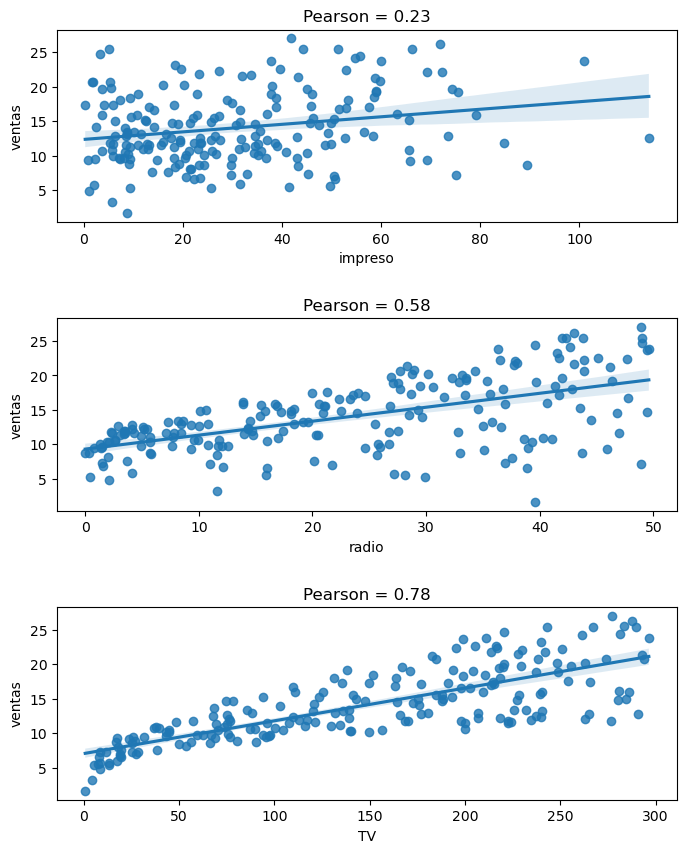

In [6]:
fig,axs=plt.subplots(3,1,figsize=(8,10))
fig.subplots_adjust(hspace=.5)
for ax,col in zip(axs,["impreso","radio","TV"]):
    coef = df['ventas'].corr(df[col])
    ax.set_title(f'Pearson = {coef:.2f}')    
    sns.regplot(df,x=col,y="ventas",ax=ax)

1. ¿Hay correlación (no causalidad) entre el nivel de publicidad y las ventas?
2. ¿Qué tan fuerte es la relación entre el nivel de publicidad y las ventas?
3. ¿Cuál de los tres tipos de publicidad contribuye más a las ventas?
4. Por cada dólar invertido en publicidad (cada medio), ¿cuál es el incremento en las ventas?
5. ¿Qué precisión tendremos al intentar pronosticar las ventas?
6. ¿Existe una relación entre la inversión en publicidad y las ventas?
7. ¿Cómo deberíamos de destinar la inversión con el fin de incrementar las ventas? Es decir, ¿qué proporción deberíamos asignar a TV, radio e impreso?

### Modelo matemático

La regresión lineal se representa con la ecuación:

$$y=\beta_0+\beta_1y+\epsilon$$

Donde:

- $y$: variable dependiente
- $x$: variable independiente
- $\beta_0$: intercepto (valor de Y cuando X = 0)
- $\beta_1$: pendiente de la recta (cuánto cambia Y cuando X aumenta en 1)
- $\epsilon$: término de error (la parte que el modelo no explica)

![Regresion Lineal Simple](./regresion_lineal_grafica.jpeg)

Terminología:

- $y$: variable a predecir
- $x$: variable predictora, covariable, *feature*
- $\widehat{y}$: predicción hecha por el modelo

Ejemplos:

- $y$: ventas
- $x$: puede ser inversión publicitaria en **uno** de estos medios: TV, radio o impreso
- $\widehat{y}$: nivel de ventas predicho por el modelo

El modelo de Regresión Lineal simple tendrá esta forma:

$$\widehat{y}=\beta_0+\beta_1x$$

donde **$\widehat{y}$** es la **predicción obtenida con el modelo** (que idealmente debería aproximarse a **$y$**)

Para el ejemplo particular que venimos analizando, podríamos construir modelos como estos:

$$\hat{ventas}=\beta_0+\beta_1 \cdot TV$$
$$\hat{ventas}=\beta_0+\beta_1 \cdot radio$$
$$\hat{ventas}=\beta_0+\beta_1 \cdot impreso$$

donde en cada caso los parámetros del modelo ($\beta_0$, $\beta_1$) serán diferentes pues estaremos relacionando diferentes variables.

#### Mínimos cuadrados ordinarios

- El objetivo es encontrar los parámetros ($\beta_0$, $\beta_1$) que **minimicen** la **suma de residuales cuadráticos**
- Un residual:
$$\epsilon_i=y_i-\hat{y}_i$$
- La suma de residuales cuadráticos (RSS, *residual sum of squares*):
$$RSS = (y_1-\beta_0-\beta_1x_1)^2+(y_2-\beta_0-\beta_1x_2)^2+(y_3-\beta_0-\beta_1x_3)^2+\dotsc+(y_n-\beta_0-\beta_1x_n)^2$$
- Expresando lo anterior en términos de sumatorias:
$$RSS=\sum_{i=1}^{n}(y_i-\beta_0-\beta_1x_i)^2$$

Así los valores de $\beta_0$ y $\beta_1$ que **minimizan** el RSS se obtienen usando cálculo diferencial:

$$\frac{\partial RSS}{\partial \beta_0}=0$$
y
$$\frac{\partial RSS}{\partial \beta_1}=0$$
donde llegamos a este resultado:
$$\beta_1=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n}(x_i-\bar{x})^2}$$
$$\beta_0=\bar{y}-\beta_1\bar{x}$$

donde:

- **$n$** es el número total de datos de entrenamiento
- **$\bar{x}$** es el promedio de los datos en la variable predictora
- **$\bar{y}$** es el promedio de los datos en la variable a predecir
- **$x_i$**, **$y_i$** es cada uno de los datos de entrenamiento

##### Ejemplo

Regresión lineal simple con la covariable "TV":
$$\hat{ventas}=\beta_0+\beta_1\cdot TV$$

In [7]:
# Variable de entrada al modelo (variable predictora)
x = df["TV"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["ventas"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(200, 1)
(200, 1)


In [8]:
# Sacamos una instancia del modelo de regresión lineal simple
mod_lin = LinearRegression()

**Entrenamos el modelo** (es decir, encontramos sus parámetros) usando el método `fit()`y el set de entrenamiento que son los datos anteriores:

In [9]:
mod_lin.fit(x,y)

LinearRegression()

In [10]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 7.032593549127694
	beta_1 = 0.04753664043301976


El modelo tiene la forma:
$$\hat{ventas}=7.03+0.047\cdot TV$$

- **Por cada dólar invertido en publicidad (en cada medio), ¿cuál es el incremento en ventas?**

Caso de la TV:

La pendiente es el parámetro $\beta_1=0.047$. Interpretación:

- Por cada 1 USD de inversión en TV se obtendrá un incremento en las ventas de 0.047 productos
- Lo cual equivale a decir que **por cada 1,000 USD de inversión en TV se venderán aproximadamente 47 productos adicionales**

El modelo (y analizando el valor de $\beta_0$), si no hay inversión en TV se venderán aproximadamente 7 unidades.

### Cómo se ajusta al modelo a los datos

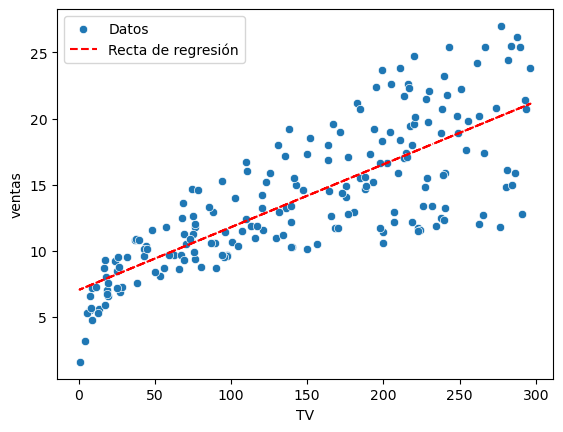

In [11]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="TV", y="ventas", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();

In [17]:
# Variable de entrada al modelo (variable predictora)
x = df["impreso"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["ventas"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(200, 1)
(200, 1)


In [18]:
# Sacamos una instancia del modelo de regresión lineal simple
mod_lin = LinearRegression()

**Entrenamos el modelo** (es decir, encontramos sus parámetros) usando el método `fit()`y el set de entrenamiento que son los datos anteriores:

In [19]:
mod_lin.fit(x,y)

LinearRegression()

In [20]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 12.351407069278162
	beta_1 = 0.05469309847227335


El modelo tiene la forma:
$$\hat{ventas}=7.03+0.047\cdot TV$$

- **Por cada dólar invertido en publicidad (en cada medio), ¿cuál es el incremento en ventas?**

Caso de la TV:

La pendiente es el parámetro $\beta_1=0.047$. Interpretación:

- Por cada 1 USD de inversión en TV se obtendrá un incremento en las ventas de 0.047 productos
- Lo cual equivale a decir que **por cada 1,000 USD de inversión en TV se venderán aproximadamente 47 productos adicionales**

El modelo (y analizando el valor de $\beta_0$), si no hay inversión en TV se venderán aproximadamente 7 unidades.

### Cómo se ajusta al modelo a los datos

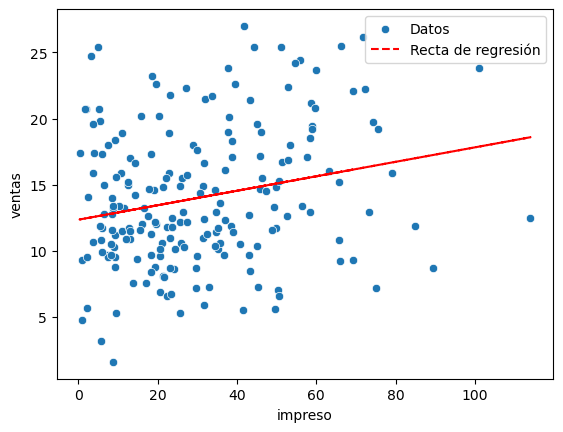

In [21]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="impreso", y="ventas", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();

In [22]:
# Variable de entrada al modelo (variable predictora)
x = df["radio"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["ventas"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(200, 1)
(200, 1)


In [23]:
# Sacamos una instancia del modelo de regresión lineal simple
mod_lin = LinearRegression()

**Entrenamos el modelo** (es decir, encontramos sus parámetros) usando el método `fit()`y el set de entrenamiento que son los datos anteriores:

In [24]:
mod_lin.fit(x,y)

LinearRegression()

In [25]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 9.311638095158283
	beta_1 = 0.20249578339243965


El modelo tiene la forma:
$$\hat{ventas}=7.03+0.047\cdot TV$$

- **Por cada dólar invertido en publicidad (en cada medio), ¿cuál es el incremento en ventas?**

Caso de la TV:

La pendiente es el parámetro $\beta_1=0.047$. Interpretación:

- Por cada 1 USD de inversión en TV se obtendrá un incremento en las ventas de 0.047 productos
- Lo cual equivale a decir que **por cada 1,000 USD de inversión en TV se venderán aproximadamente 47 productos adicionales**

El modelo (y analizando el valor de $\beta_0$), si no hay inversión en TV se venderán aproximadamente 7 unidades.

### Cómo se ajusta al modelo a los datos

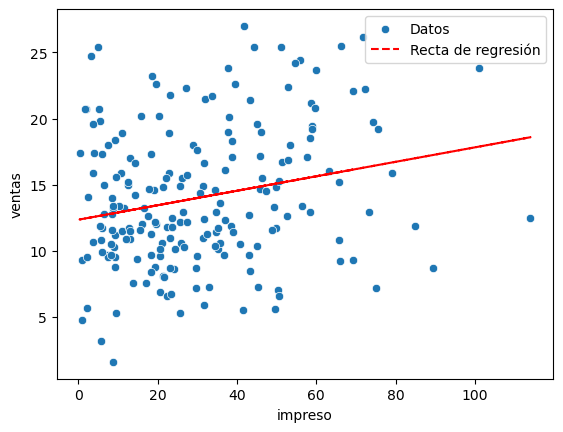

In [21]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="impreso", y="ventas", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();